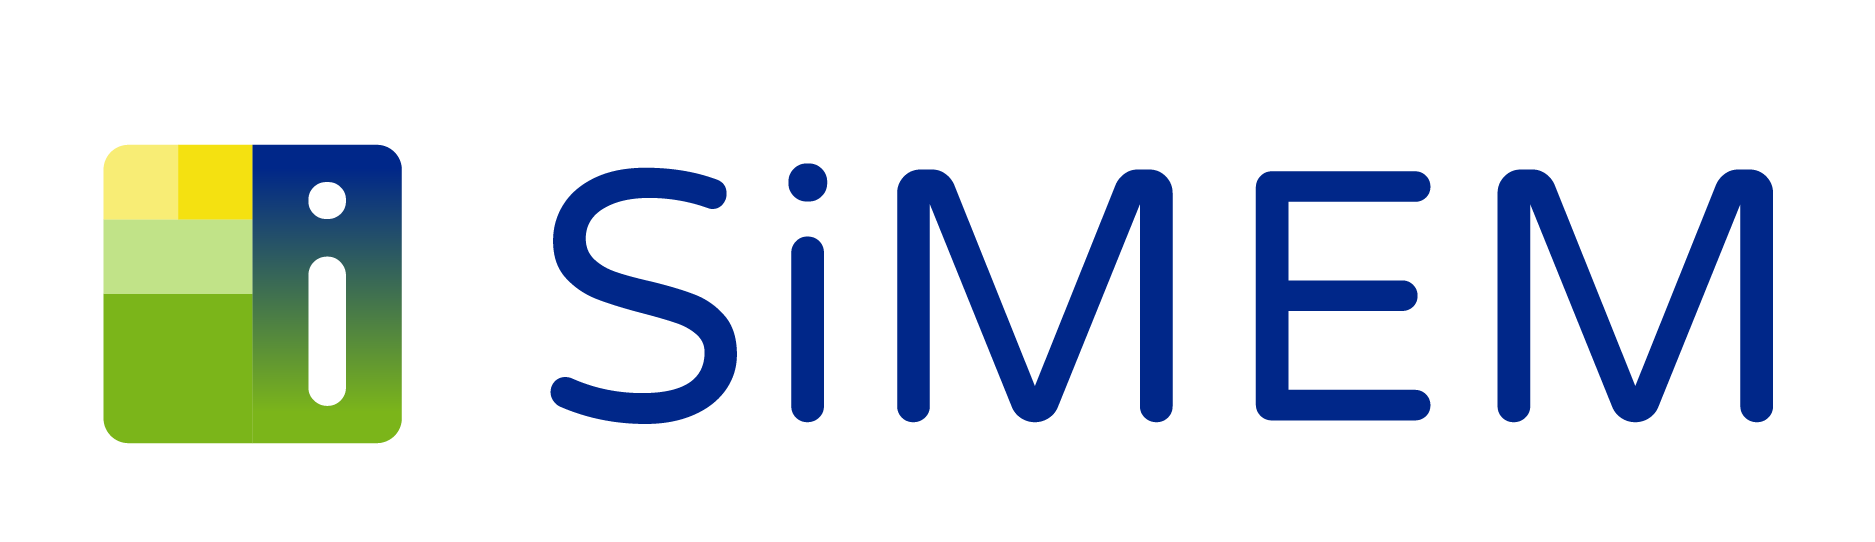

[SiMEM](https://www.simem.co/)

## Caso de uso - Energía total en contratos y bolsa nacional por los agentes vendedores, desagregada por contratos (Regulado, No Regulado) y Bolsa Nacional.


# Objetivos de este Notebook

* Explicar cómo se realiza la instalación e importación de la librería pydataxm desde la consola para su uso en ambientes locales
* Explicar cómo se pueden consultar los conjuntos de datos a través de la librería Pydataxm
* Explicar cómo realizar el procesamiento y manipulación de los datos consultados
* Explicar el análisis de los datos consultados para dar respuesta al caso de uso propuesto

**Índice**

1. [Instalación de librerías](#section1)

2. [Importación de librerías](#section2)

3. [Consultar información de los conjuntos de datos](#section3)

4. [Manipulación de datos](#section4)

5. [Análisis para dar respuesta al caso de uso](#section5)


<a id='section1'></a>
# 1. Instalación de la librería
Ejecutar el siguiente comando en el CMD para instalar la librería de python.

In [1]:
# !{sys.executable} -m pip install pydataxm

<a id='section2'></a>
# 2. Importación de librerías


In [1]:
from pydataxm.pydatasimem import ReadSIMEM, VariableSIMEM  # Importa clases para interactuar con datos del sistema SIMEM
import pandas as pd                             # Librería para manipulación y análisis de datos en estructuras tipo DataFrame
import datetime as dt                           # Módulo para trabajar con fechas y horas
from datetime import timedelta                  # Importa la clase timedelta para operaciones con diferencias de tiempo
import matplotlib.pyplot as plt                 # Importa la librería matplotlib para graficar
from pandas import CategoricalDtype             # Importa CategoricalDtype para definir tipos de datos categóricos en pandas
pd.options.mode.chained_assignment = None       # Desactiva el warning

<a id='section3'></a>
# 3. Consultar información de los conjuntos de datos
El método de extracción recibe los parámetros con los que se va a realizar la consulta. 
El datasetID para un conjunto particular se puede encontrar en el [catálogo de conjuntos de datos.](https://www.simem.co/pages/catalogodatos/51FC0A59-3A00-462C-B449-9CB8D5E007FB)  
Para este ejemplo los conjuntos de datos a consultar son:  

+ [Cantidades en contratos de energía del Mercado Mayorista por vendedor](https://www.simem.co/datadetail/31669D37-54E3-4AE8-8555-99F5327B1227)
+ [Magnitud ventas en bolsa nacional en energía](https://www.simem.co/datadetail/E14D7065-B324-472D-9ED4-9D78A91917B8)

Inicialmente se defina el rango de fecha para la consulta, el cual se puede modificar según el interés del análisis

In [2]:
fecha_inicial = '2025-12-01'                                # Fecha de inicio del rango de consulta
fecha_final = '2026-02-28'                                  # Fecha de fin del rango de consulta

Teniedo el rango de fecha ya definido, se proporcionan los dataserID de los conjuntos de datos a consultar, y se crea el objeto ReadSIMEM() para realizar las consultas.

In [3]:

id_dataset_contratos = '31669d'                                       # ID del conjunto de datos a consultar
simem = ReadSIMEM(id_dataset_contratos, fecha_inicial, fecha_final)   # Instancia de la clase ReadSIMEM con los parámetros definidos
ener_contratos_df = simem.main()                                      # Ejecución del método principal para obtener los datos en un DataFrame
display(ener_contratos_df.head(20))                                   # Visualización de las primeras 20 filas del DataFrame

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Cantidades en contratos de energía del Mercado Mayorista por vendedor"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0
Extraccion de registros: 14.84993600845337
End of data extracting process
****************************************************************************************************


,Fecha,CodigoVariable,CodigoAgenteVendedor,TipoMercado,Mecanismo,NormatividadRelacionada,Valor,Version
0,2025-12-31,EnergiaContratoLP,EGTC,Regulado,Por fuera del SICEP,Resolución CREG 101 067 del 2024,240000.00,TXF
1,2025-12-31,EnergiaContratoLP,EPSG,Regulado,Antes del SICEP,Resolución CREG 020 del 1996,1587869.00,TXF
2,2025-12-31,EnergiaContratoLP,EPSG,No Regulado,Mecanismos de Comercialización,Resolución MME 40590 del 2019,109236.41,TX3
3,2025-12-31,EnergiaContratoLP,EGTC,No Regulado,Negociación Bilateral,Resolución CREG 024 del 1995,584209.24,TXF
4,2025-12-31,EnergiaContratoLP,SPRG,No Regulado,Negociación Bilateral,Resolución CREG 024 del 1995,1745192.84,TXF
5,2025-12-31,EnergiaContratoLP,SOUC,No Regulado,Negociación Bilateral,Resolución CREG 024 del 1995,120000.00,TX3
6,2025-12-31,EnergiaContratoLP,ADCG,No Regulado,Negociación Bilateral,Resolución CREG 024 del 1995,172094.40,TX3
7,2025-12-31,EnergiaContratoLP,SDCG,Regulado,Mecanismos de Comercialización,Resolución MME 40590 del 2019,199406.50,TXR
8,2025-12-31,EnergiaContratoLP,ERNC,No Regulado,Negociación Bilateral,Resolución CREG 024 del 1995,8400.00,TXF
9,2025-12-31,EnergiaContratoLP,ERRG,Regulado,SICEP,Resolución CREG 130 del 2019,168300.15,TX3


In [4]:
id_dataset_bolsa = 'E14D70'                                       # ID del conjunto de datos a consultar
simem = ReadSIMEM(id_dataset_bolsa, fecha_inicial, fecha_final)   # Instancia de la clase ReadSIMEM con los parámetros definidos
ener_bolsa_nacional_df = simem.main()                             # Ejecución del método principal para obtener los datos en un DataFrame
display(ener_bolsa_nacional_df.head(20))                          # Visualización de las primeras 20 filas del DataFrame

****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Magnitud ventas en bolsa nacional en energía"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0
Extraccion de registros: 90.8274598121643
End of data extracting process
****************************************************************************************************


,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,CodigoSICAgente,Version,Valor
0,MgVB,2025-12-31 00:00:00,PT1H,kWh,CEOC,TXF,1634.64
1,MgVB,2025-12-31 09:00:00,PT1H,kWh,ESVC,TXF,101.01
2,MgVB,2025-12-31 12:00:00,PT1H,kWh,SFEG,TXF,0.00
3,MgVB,2025-12-31 19:00:00,PT1H,kWh,IACG,TXF,0.00
4,MgVB,2025-12-31 05:00:00,PT1H,kWh,SPRG,TXF,0.00
5,MgVB,2025-12-31 22:00:00,PT1H,kWh,SPRG,TXF,0.00
6,MgVB,2025-12-31 11:00:00,PT1H,kWh,TCNG,TXF,0.00
7,MgVB,2025-12-31 01:00:00,PT1H,kWh,EDPC,TXF,0.00
8,MgVB,2025-12-31 04:00:00,PT1H,kWh,ENBC,TXF,5404.03
9,MgVB,2025-12-31 09:00:00,PT1H,kWh,GPEC,TXF,996.52


<a id='section4'></a>
# 4. Manipulación de datos
Los siguientes pasos corresponden a las actividades de manipulación y preparación de los datos que son relevantes para el análisis. 

### Filtrado de Vendedores
El metodo de filtra el conjunto de datos de se le ingrese, para extraer únicamente la información de los agentes vendedores, que en su código SIC, finaliza con la letras *"G"*.

In [5]:
def filtrar_comercializadores(df,columna_codigo_comercializador):
    
    filtro = df[columna_codigo_comercializador].str.endswith('G')  # Crea un filtro para filas donde el código del vendedores termina con 'G'
    
    return df[filtro]  # Devuelve el DataFrame filtrado con solo los comercial

### Filtrar y acumular la columna de interés para la máxima versión del periodo de consulta de los datos
Dado que en los conjuntos de datos se pueden encontrar varias versiones para un mismo periodo, se realiza un filtrado para obtener únicamente la versión que contiene la información más actualizada.

El método de acumulación recibe como parámetros el DataFrame a acumular, la columna de fecha, las columnas por las cuales se va a realizar la agrupación, la columna que contiene los valores a acumular y la frecuencia con la que se desea acumular (en este caso mensual).

> **NOTA:** La acumulación se puede realizar con las frecuencias Diaria (D), Mensual (ME, *Valor por defecto*), Trimestral (QE) o Anual (YE).

Dado que la granularidad mínima de uno de los conjuntos de datos es diaria, no es posible realizar la acumulación con una frecuencia menor a esta.

In [6]:
def definir_categorias_version(df, columna_version):
   
    versiones_categoria = CategoricalDtype(categories= ['TX1', 'TX2', 'TXR', 'TXF'] + ["TX" + str(i) for i in range(3, 25)], ordered=True)
    df[columna_version] = df[columna_version].astype(versiones_categoria)  # Convierte la columna de versión a tipo categórico con el orden definido
    
    return df

def acumular_valores(df, columna_fecha, columnas_agrupacion, columna_valor, frecuencia='ME'):
    
    redefined_df = definir_categorias_version(df, 'Version')  # Asegura que la columna 'Version' esté definida como categórica con el orden correcto
    
    redefined_df[columna_fecha] = pd.to_datetime(redefined_df[columna_fecha])  # Convierte la columna de fecha a formato datetime
    grouped_df = redefined_df.groupby([pd.Grouper(key=columna_fecha, freq=frecuencia)] + columnas_agrupacion)
    cummuled_df = grouped_df.apply(lambda x: x.loc[x['Version'] == x['Version'].max(),columna_valor].sum())
    
    return cummuled_df.rename('Acumulado_' + columna_valor)  # Devuelve el DataFrame con los valores acumulados, apilado y renombrado para claridad

En esta celda se debe definir la frecuencia con la que se desea acumular la información, y se aplican los métodos de filtrado y acumulación a cada uno de los conjuntos de datos consultados.

In [7]:
frec = 'ME'  # Frecuencia mensual para resampleo
contratos_comer_df = filtrar_comercializadores(ener_contratos_df, "CodigoAgenteVendedor")
bolsa_nacional_comer_df = filtrar_comercializadores(ener_bolsa_nacional_df, "CodigoSICAgente")
mensual_contratos = acumular_valores(contratos_comer_df, "Fecha", ["CodigoAgenteVendedor","TipoMercado"], "Valor", frecuencia=frec)
mensual_bolsa_nacional = acumular_valores(bolsa_nacional_comer_df, "FechaHora", ["CodigoSICAgente"], "Valor", frecuencia=frec)

C:\Users\50396\AppData\Local\Temp\ipykernel_40892\1050325250.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cummuled_df = grouped_df.apply(lambda x: x.loc[x['Version'] == x['Version'].max(),columna_valor].sum())
C:\Users\50396\AppData\Local\Temp\ipykernel_40892\1050325250.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cummuled_df = grouped_df.apply(lambda x: x.loc[x['Version'] == x['Version'].max(),column

In [8]:
mensual_contratos = mensual_contratos.unstack('TipoMercado').reset_index()
mensual_bolsa_nacional = mensual_bolsa_nacional.reset_index()

In [9]:
df_resultado = mensual_contratos.merge(mensual_bolsa_nacional, 
                             left_on=['CodigoAgenteVendedor', 'Fecha'], 
                             right_on=['CodigoSICAgente', 'FechaHora'], how = 'outer') # Realiza un merge entre los DataFrames de contratos y bolsa nacional utilizando las columnas de código de agente y fecha como claves, con un tipo de unión externa para conservar todos los registros

df_resultado.rename(columns={"Acumulado_Valor":"Bolsa Nacional"}, inplace=True) # Renombra la columna de valor acumulado de la bolsa nacional para mayor claridad

df_resultado[['No Regulado','Regulado','Bolsa Nacional']] = df_resultado[['No Regulado','Regulado','Bolsa Nacional']].fillna(0) # Rellena los valores nulos en las columnas de No Regulado, Regulado y Bolsa Nacional con 0 para evitar problemas en análisis posteriores
df_resultado.drop(columns=['CodigoAgenteVendedor', 'Fecha'], inplace=True) # Elimina las columnas de código de agente vendedor y fecha del DataFrame, ya que no son necesarias para el análisis posterior



df_resultado['Fecha'] = df_resultado['FechaHora'].dt.to_period(frec[0]) # Convierte la columna de FechaHora a un formato de fecha mensual, estableciendo el día como el primer día del mes

df_resultado = df_resultado[['CodigoSICAgente', 'Fecha','Regulado', 'No Regulado', 'Bolsa Nacional']] # Reorganiza las columnas del DataFrame para tener el código del agente, fecha y las cantidades de regulado, no regulado y bolsa nacional en un orden específico

<a id='section5'></a>
# 5. Análisis para dar respuesta al caso de uso

### Calcular la energía total despachada al agente en el periodo de análisis.
El siguiente código realiza la suma la energía por contratos (Regulado y No Regulado) y la energía de la Bolsa Nacional para obtener el total de energía por cada agente en cada período de tiempo.

In [10]:
df_resultado['Energía Total'] = df_resultado[['Regulado', 'No Regulado', 'Bolsa Nacional']].sum(axis=1) # Calcula la suma total de las columnas de Regulado, No Regulado y Bolsa Nacional para obtener el total de energía despachada por cada agente en cada mes.
df_resultado

,CodigoSICAgente,Fecha,Regulado,No Regulado,Bolsa Nacional,Energía Total
0,AAGG,2025-12,0.0,12151471.10,0.0,12151471.10
1,AAGG,2026-01,0.0,13047486.73,0.0,13047486.73
2,AAGG,2026-02,0.0,12339496.77,0.0,12339496.77
3,ABAG,2025-12,0.0,2217525.70,0.0,2217525.70
4,ABAG,2026-01,0.0,8472151.90,0.0,8472151.90
...,...,...,...,...,...,...
351,VESG,2026-02,0.0,329345.75,4801.8,334147.55
352,VNRG,2025-12,0.0,0.00,0.0,0.00
353,VNRG,2026-01,0.0,0.00,0.0,0.00
354,VNRG,2026-02,0.0,0.00,0.0,0.00


A continuación, se realiza un gráfico de barras apiladas para visualizar la energía total por un top 10 de agentes vendedores, desagregada por mercado (Regulado, No Regulado y Bolsa Nacional).

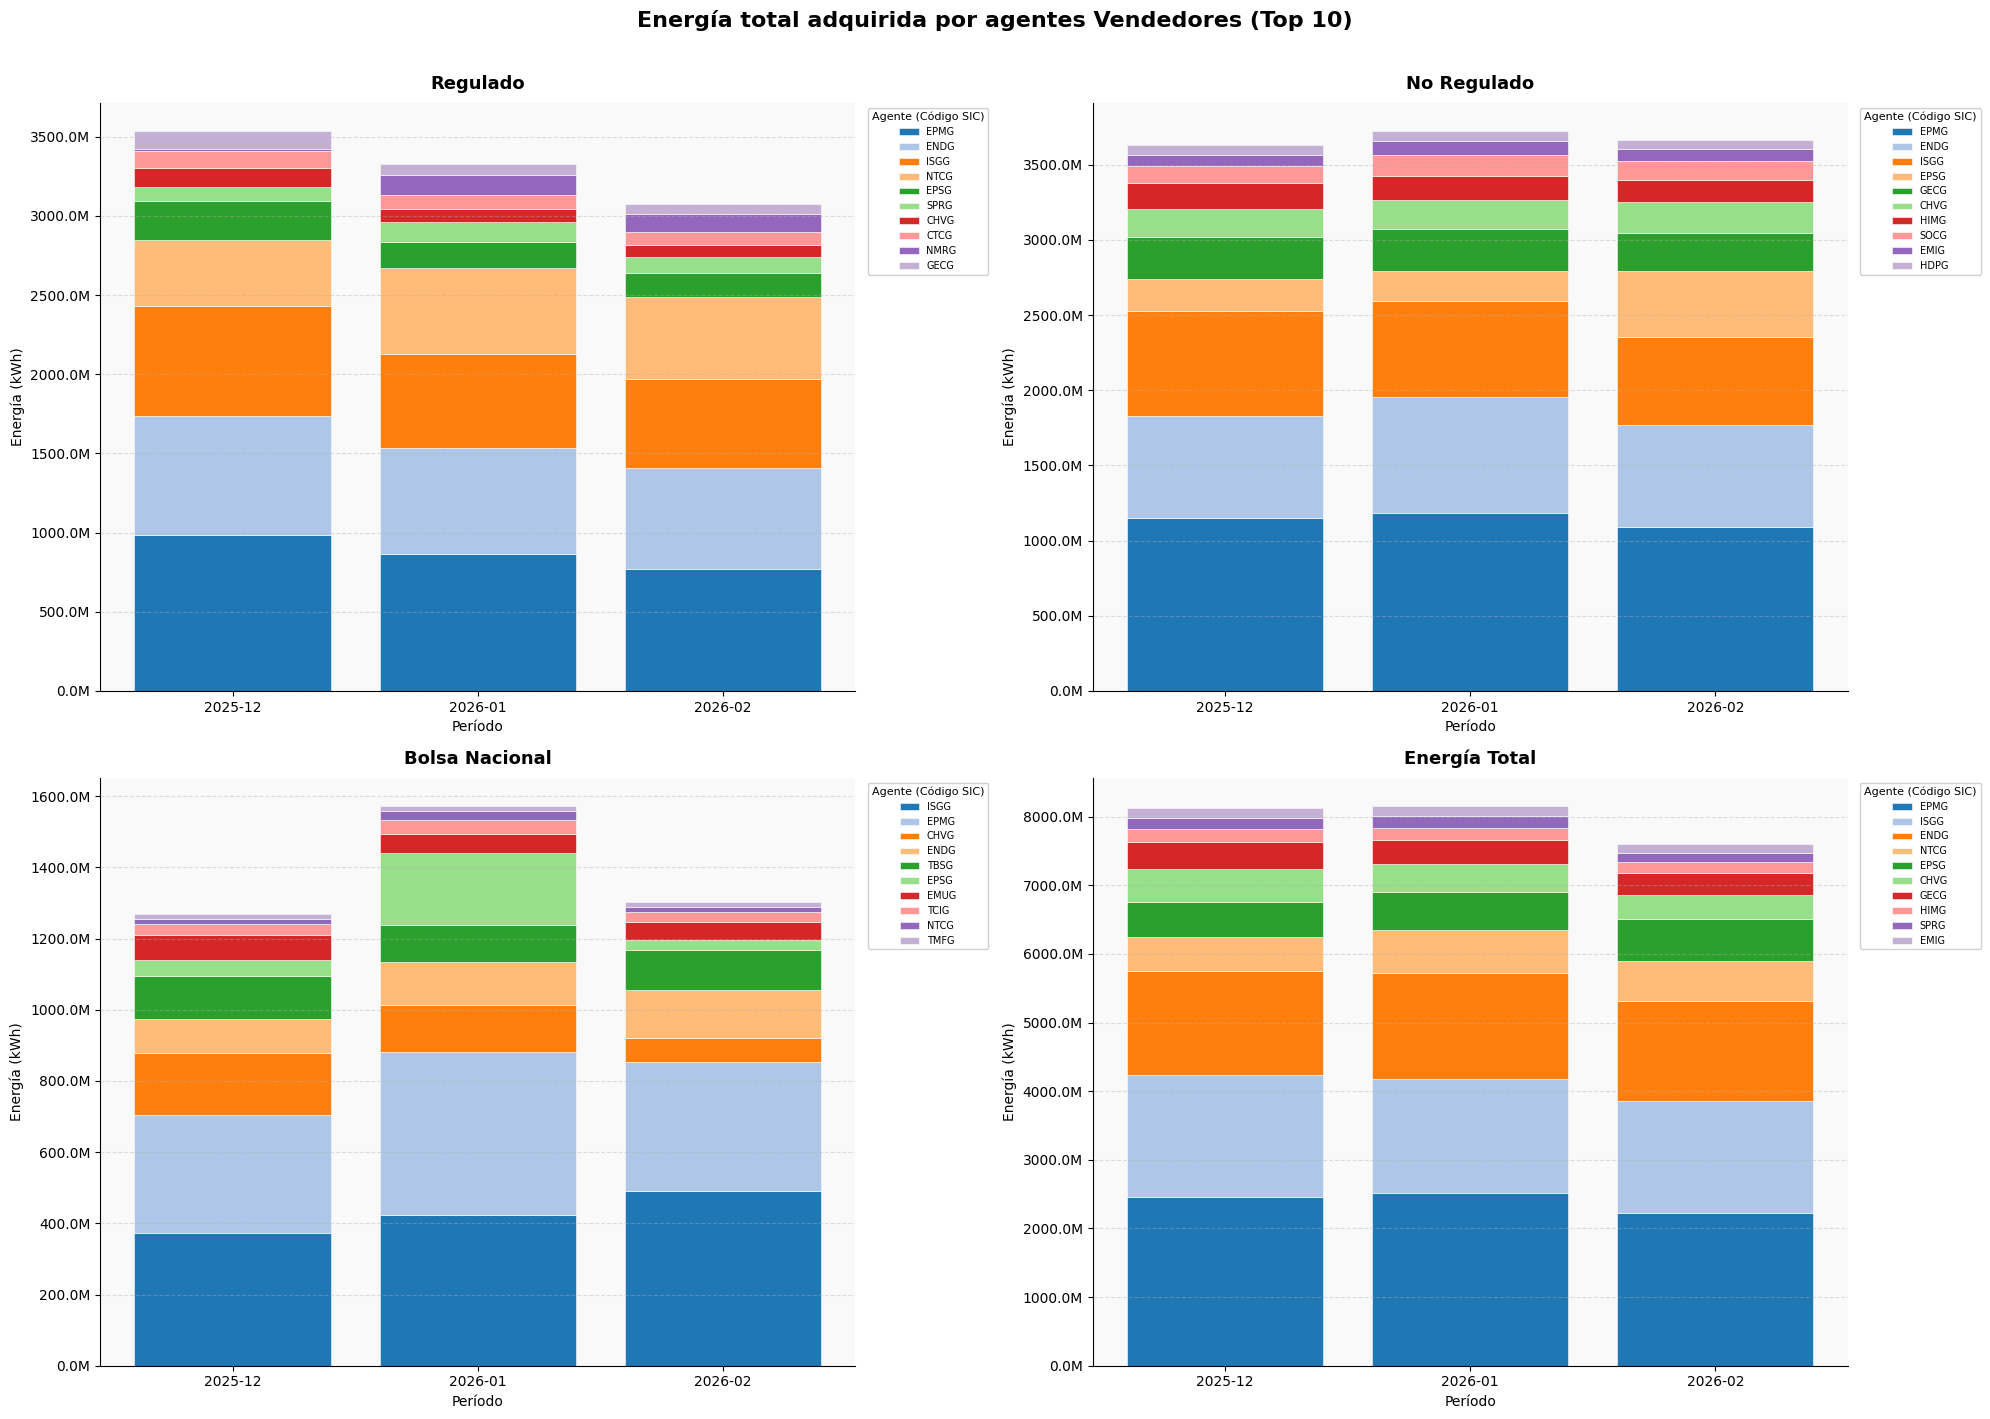

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Energía total adquirida por agentes Vendedores (Top 10)', fontsize=16, fontweight='bold', y=1.01)

columnas = ['Regulado', 'No Regulado', 'Bolsa Nacional', 'Energía Total']

for ax, columna in zip(axes.flatten(), columnas):
    pivot = df_resultado.pivot_table(index='Fecha', columns='CodigoSICAgente', values=columna, aggfunc='sum').fillna(0)
    
    # Seleccionar top 20 agentes por suma total en la columna
    top20_agentes = pivot.sum().nlargest(10).index
    pivot_top20 = pivot[top20_agentes]
    
    colores_top20 = plt.cm.tab20.colors
    color_map_top20 = {agente: colores_top20[i % len(colores_top20)] for i, agente in enumerate(top20_agentes)}
    
    bottom = pd.Series([0.0] * len(pivot_top20), index=pivot_top20.index)
    
    for agente in pivot_top20.columns:
        ax.bar(pivot_top20.index.astype(str), pivot_top20[agente], bottom=bottom,
               label=agente, color=color_map_top20[agente], edgecolor='white', linewidth=0.4)
        bottom += pivot_top20[agente]
    
    ax.set_title(columna, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Período', fontsize=10)
    ax.set_ylabel('Energía (kWh)', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_facecolor('#f9f9f9')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    # Leyenda individual por subplot
    ax.legend(title='Agente (Código SIC)', bbox_to_anchor=(1.01, 1), loc='upper left',
              fontsize=7, title_fontsize=8, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

### Filtrado por agente

En esta sección se define un método para filtrar la información por agente, el cual recibe como parámetros el DataFrame a filtrar y el código del agente de interés.

In [12]:
def filtrar_por_agente(df, codigo_agente):
    return df[df['CodigoSICAgente'] == codigo_agente]

In [13]:
df_filtrado = filtrar_por_agente(df_resultado, 'ENDG')
df_filtrado

,CodigoSICAgente,Fecha,Regulado,No Regulado,Bolsa Nacional,Energía Total
110,ENDG,2025-12,7.565653e+08,6.751406e+08,9.387543e+07,1.525581e+09
111,ENDG,2026-01,6.674553e+08,7.667996e+08,1.216962e+08,1.555951e+09
112,ENDG,2026-02,6.421845e+08,6.802641e+08,1.348936e+08,1.457342e+09


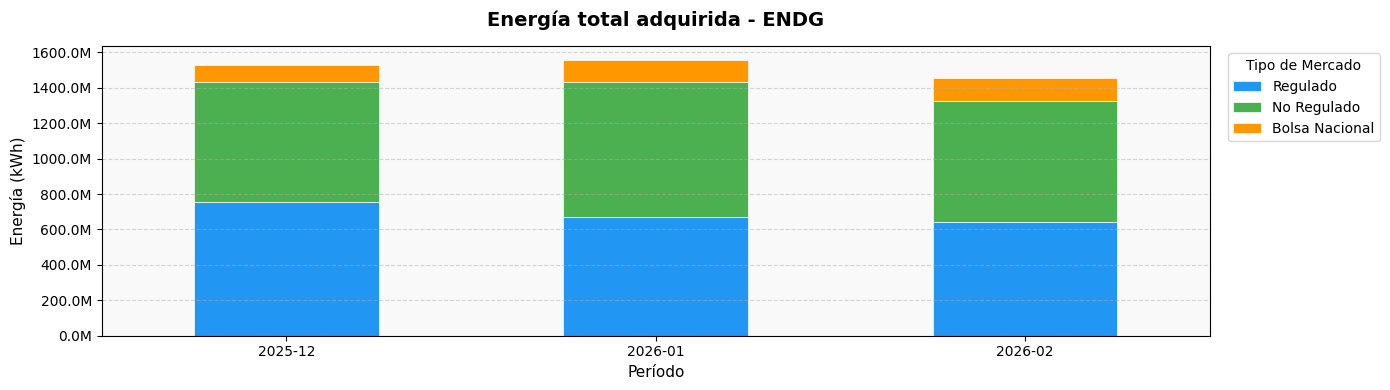

In [14]:
ax = df_filtrado.set_index('Fecha')[['Regulado', 'No Regulado', 'Bolsa Nacional']].plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 4),                                    # Más ancho y menos alto
    color=['#2196F3', '#4CAF50', '#FF9800'],            # Colores más atractivos
    edgecolor='white',                                  # Borde blanco entre barras
    linewidth=0.5
)

ax.set_title(f'Energía total adquirida - {df_filtrado["CodigoSICAgente"].iloc[0]}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Período', fontsize=11)
ax.set_ylabel('Energía (kWh)', fontsize=11)
ax.tick_params(axis='x', rotation=0)                   # Etiquetas del eje X horizontales
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))  # Formato en millones
ax.legend(title='Tipo de Mercado', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)  # Leyenda fuera del gráfico
ax.grid(axis='y', linestyle='--', alpha=0.5)           # Líneas de cuadrícula suaves
ax.set_facecolor('#f9f9f9')                            # Fondo gris claro
plt.tight_layout()
plt.show()